In [1]:
### Importing the required library 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import MolStandardize
import joblib

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors,rdMolDescriptors
#import openpyxl


# Environment - env

### Installation of the basic library 
from rdkit import Chem,DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen



In [2]:
### Reading the preprocess data from disk 
### Train data 
train_set=pd.read_csv('final_data/final_unique_train.csv')

### test data 
test_set=pd.read_csv('final_data/final_unique_test.csv')

print(train_set.shape)
print(test_set.shape)

(17937, 8)
(1282, 8)


In [3]:
### Making smiles to list 
train_smiles_list=train_set[['smiles_canon']]
test_smiles_list=test_set[['smiles_canon']]

In [5]:
import Script.utilities as utilities

In [6]:
### Generate 4 descriptors ....
df4_train=utilities.generate4(train_set.smiles_canon)
df4_test=utilities.generate4(test_set.smiles_canon)
### Generate 17 descriptors ....
df17_train=utilities.generate17(train_set.smiles_canon)
df17_test=utilities.generate17(test_set.smiles_canon)
### Generate 123 descriptors ....'''
df123_train=utilities.generate123(train_set.smiles_canon)
df123_test=utilities.generate123(test_set.smiles_canon)
### Generate 38 feature engineered based on the structure of the smiles ....
df38_train=utilities.generate_features38(train_set.smiles_canon)
df38_test=utilities.generate_features38(test_set.smiles_canon)
### Generate 7 funnctional groups
df7_train=utilities.get_functional_groups(train_set.smiles_canon)
df7_test=utilities.get_functional_groups(test_set.smiles_canon)
### Fingerprint 128....
df128_train=utilities.fingerprint(train_set.smiles_canon,2,128)
df128_test=utilities.fingerprint(test_set.smiles_canon,2,128)


## Prof. Ulf proposed data
df96_train=utilities.generate_desc_96(train_set.smiles_canon)
df96_test=utilities.generate_desc_96(test_set.smiles_canon)

## Prof. Ulf + chatgpt suggested data
df193_train=utilities.generate_desc_193(train_set.smiles_canon)
df193_test=utilities.generate_desc_193(test_set.smiles_canon)

In [7]:
y_train=train_set.copy()['LogS']
y_test=test_set.copy()['LogS']

In [8]:
### Importing library to evaluate the best model 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgboost
from xgboost import XGBRegressor
import xgboost #as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score #, root_mean_squared_error
import numpy as np
from sklearn.random_projection import GaussianRandomProjection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
### 125 and 128 fingerprint  
df253_train=pd.concat([df123_train, df128_train], axis=1)
df253_test=pd.concat([df123_test, df128_test], axis=1)


In [10]:
### 125 standard features , 128 fingerprint  7 functional group 
df260_train=pd.concat([df253_train, df7_train], axis=1)
df260_test=pd.concat([df253_test, df7_test], axis=1)

In [11]:
### 125 + 128 fp and 7 functional group + 38 featured engineered 
df298_train=pd.concat([df260_train, df38_train], axis=1)
df298_test=pd.concat([df260_test, df38_test], axis=1)

# pytohn scripts  Data (PRof. Ulf Sent)

In [12]:
df394_train=pd.concat([df298_train, df96_train], axis=1)
df394_test=pd.concat([df298_test, df96_test], axis=1)

In [13]:
df491_train=pd.concat([df298_train, df193_train], axis=1)
df491_test=pd.concat([df298_test, df193_test], axis=1)

### FEature importance Function

In [14]:

def feat_importance(model, data):
    xgboost_model = model
    df298_train = data
    feature_importance = xgboost_model.feature_importances_

    # Convert to DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': df298_train.columns,
        'Importance': feature_importance
    })

    # Sort by importance (highest to lowest)
    feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

    # Plot the top 20 most important features
    plt.figure(figsize=(12, 6), dpi=300)  # High resolution
    plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20], color='royalblue')

    # Labels and Title (Bold)
    plt.xlabel("Feature Importance Score", fontsize=14, fontweight='bold')
    plt.ylabel("Features", fontsize=14, fontweight='bold')
    plt.title("Figure A - Top 20 Most Important Features (XGBoost)", fontsize=16, fontweight='bold')

    # Make both x-axis and y-axis labels bold
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

    # Invert y-axis for better readability
    plt.gca().invert_yaxis()

    # Save the figure with high resolution
    plt.savefig("xgboost_top20_features.png", dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()

# Train 

In [15]:
def drop_nan(X, y):
    XY = pd.concat([X, y], axis=1, join="inner")          # align on index
    XY = XY.replace([np.inf, -np.inf], np.nan)

    dropped = XY.isna().any(axis=1).sum()
    XY = XY.dropna(axis=0, how="any")
    n_features = X.shape[1]
    X_clean = XY.iloc[:, :n_features]
    y_clean = XY.iloc[:, n_features]
    return X_clean, y_clean

### xgboost for 298 features

In [96]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model.fit(df298_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df298_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_298=utilities.get_errors1(y_test,pred_xgb,"XGB_298")
xgb_298['Descriptors_Detail']='125 features + 128 fingerprint 7 f_group+38 fe features'

In [54]:
xgb_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_298,0.4084,0.3047,0.552,0.927,125 features + 128 fingerprint 7 f_group+38 fe...


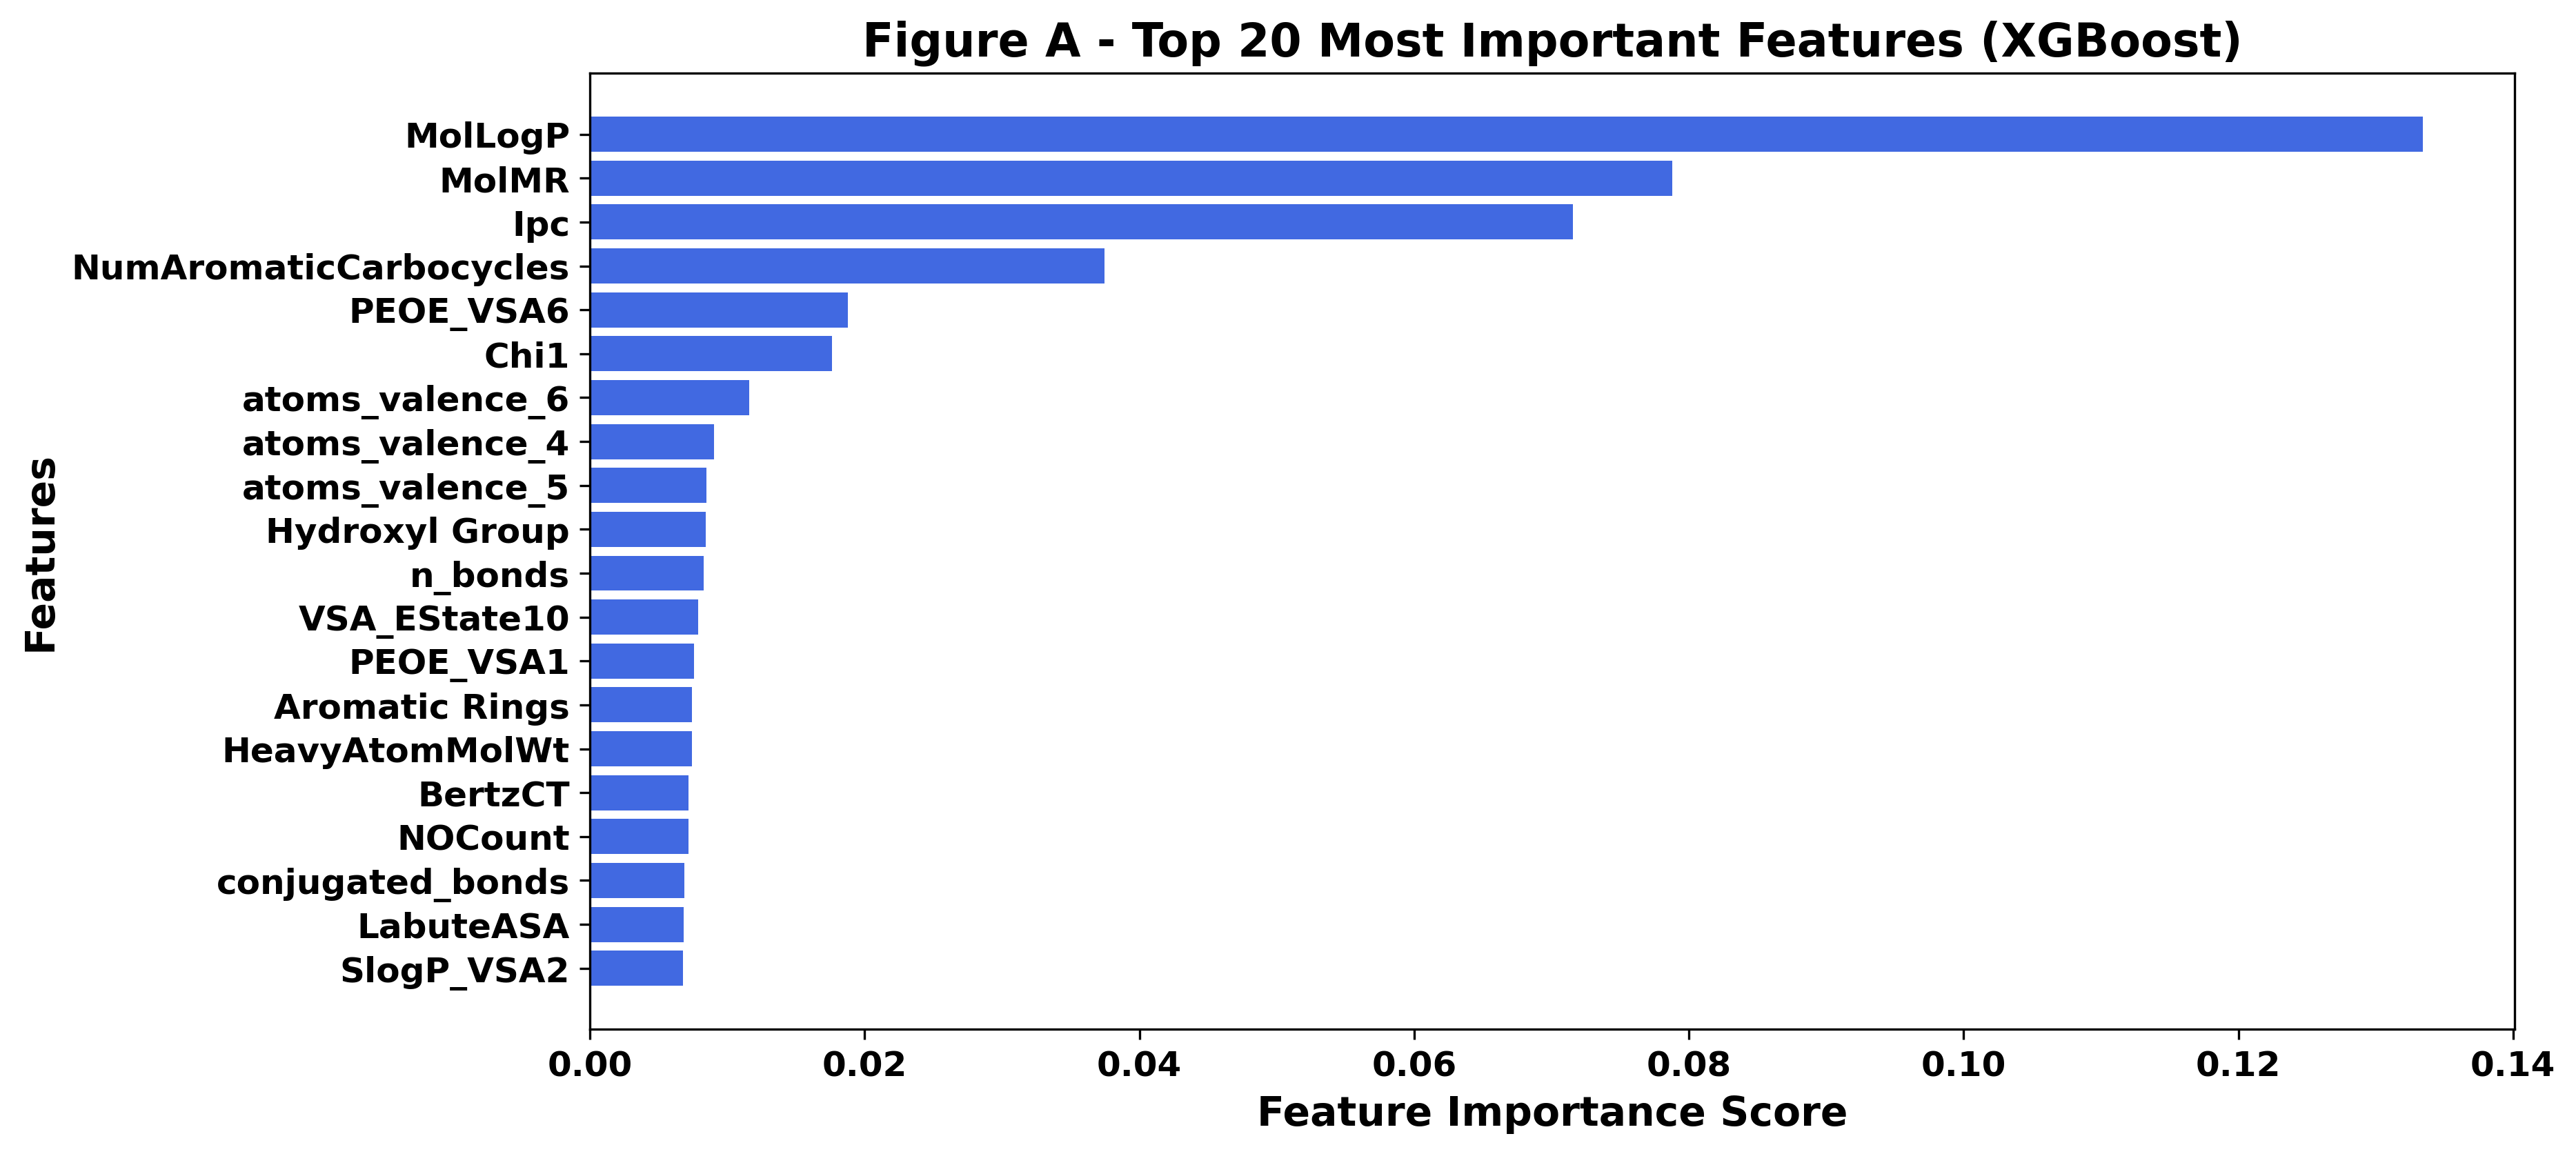

In [97]:
feat_importance(model=xgboost_model, data=df298_train)

### Random Forest for 298 features

In [85]:
randomforest_model = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=0
    )

df298_train_rf, y_train_rf  = drop_nan(X=df298_train, y=y_train)
df298_test_rf, y_test_rf  = drop_nan(X=df298_test, y=y_test)

print(f"XGB Datset Length; train: {len(df298_train)}  test  {len(df298_test)}")
print(f"RF Datset Length; train: {len(df298_train_rf)}  test  {len(df298_test_rf)}")

randomforest_model.fit(df298_train_rf,y_train_rf)

pred_rf = randomforest_model.predict(df298_test_rf)

rf_298=utilities.get_errors1(y_test_rf,pred_rf,"RF_298")
rf_298['Descriptors_Detail']='298 features'

XGB Datset Length; train: 17937  test  1282
RF Datset Length; train: 17522  test  1281


In [82]:
rf_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,RF_298,0.4401,0.3351,0.5789,0.9196,298 features


## Suport Vector Regression + RBF

In [109]:
from sklearn.svm import SVR
c = [0.1, 0.3, 0.5, 0.8, 1, 2, 5, 8, 10]
for i in c:
    svr_298 = SVR(kernel="rbf", C=i, epsilon=0.1, gamma="scale")  # scale uses 1/(n_features * X.var)
    svr_298.fit(df298_train_rf,y_train_rf)   # standardize X first!
    y_pred = svr_298.predict(df298_test_rf)

    svr_298=utilities.get_errors1(y_test_rf,y_pred,"RF_298")
    svr_298['Descriptors_Detail']='298 features'
    print(i, svr_298)

0.1   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
0.3   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
0.5   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
0.8   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
1   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
2   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
5   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0     RF_298  1.6053  4.1764  2.0436  -0.0021       298 features
8   Model_Name     MAE     MSE    RMSE       R2 Descriptors_Detail
0

In [108]:
svr_298

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,RF_298,1.6053,4.1764,2.0436,-0.0021,298 features


### xgboost for 96 features

In [98]:
xgboost_model_96 = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model_96.fit(df96_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model_96.predict(df96_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_96=utilities.get_errors1(y_test,pred_xgb,"XGB_96")
xgb_96['Descriptors_Detail']='96 features'

In [56]:
xgb_96

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_96,0.4179,0.3218,0.5673,0.9228,96 features


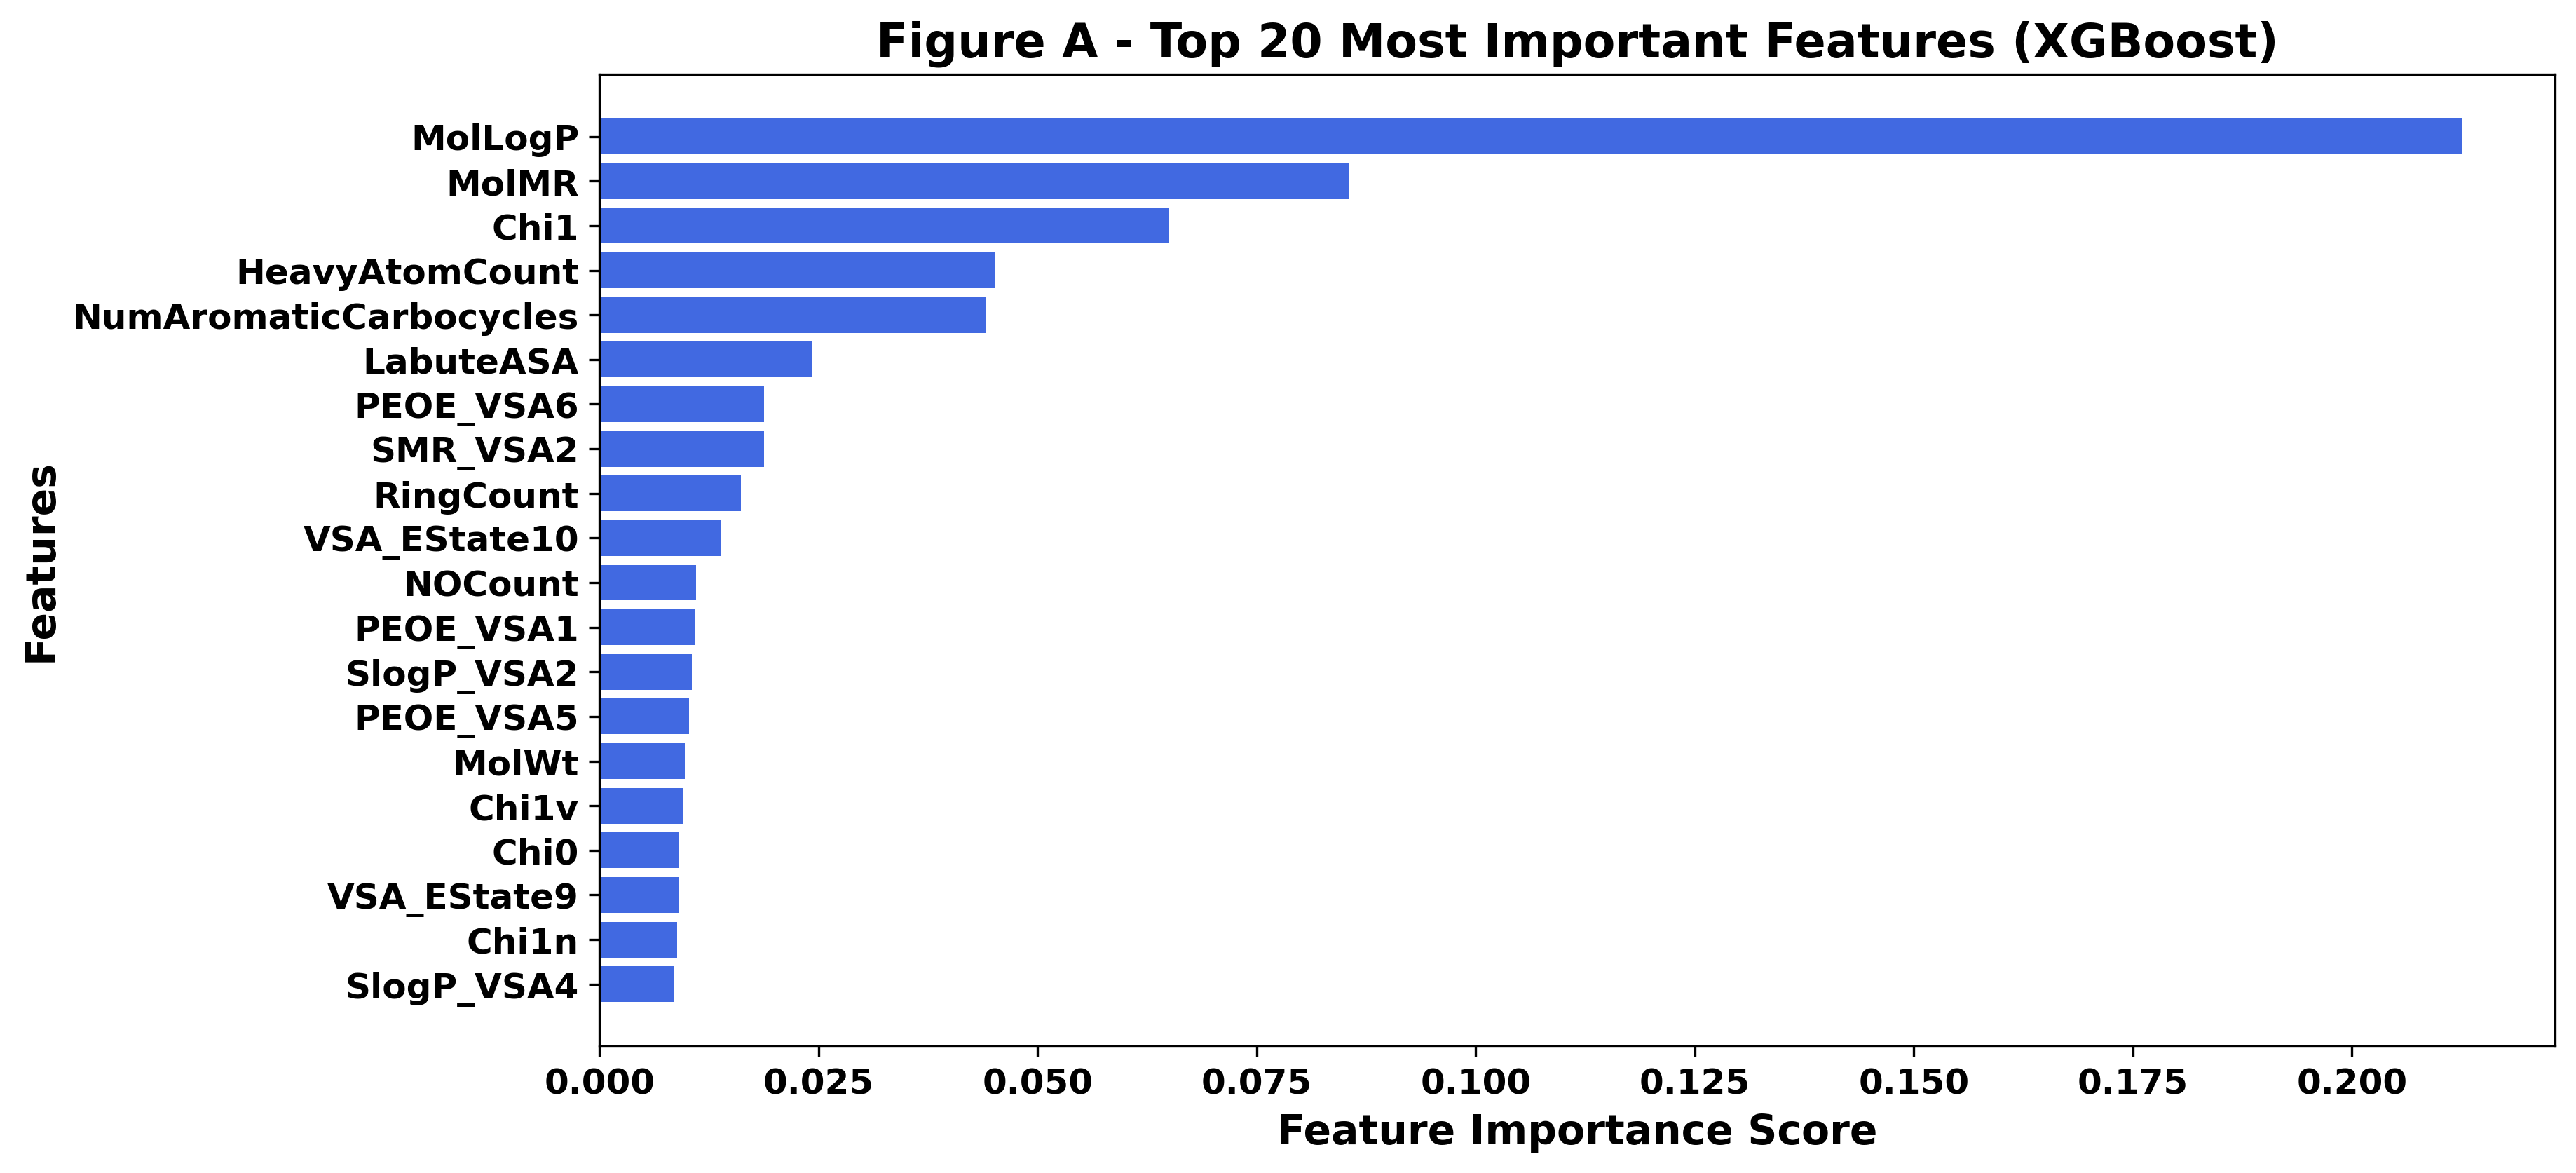

In [99]:
feat_importance(model=xgboost_model_96, data=df96_train)

## Random forest 96

In [86]:
randomforest_model = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=0
    )

randomforest_model.fit(df96_train,y_train)

print(f"Datset Length; train: {len(df96_train)}  test  {len(df96_test)}")

pred_rf = randomforest_model.predict(df96_test)

rf_96=utilities.get_errors1(y_test,pred_xgb,"RF_96")
rf_96['Descriptors_Detail']='96 features'


Datset Length; train: 17937  test  1282


In [71]:
rf_96

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_96,0.4114,0.3108,0.5575,0.9255,96 features


### xgboost for 193 features

In [100]:
xgboost_model_193 = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 
xgboost_model_193.fit(df193_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model_193.predict(df193_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_193=utilities.get_errors1(y_test,pred_xgb,"XGB_193")
xgb_193['Descriptors_Detail']='193 features'

In [58]:
xgb_193

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_193,0.4136,0.3178,0.5637,0.9238,193 features


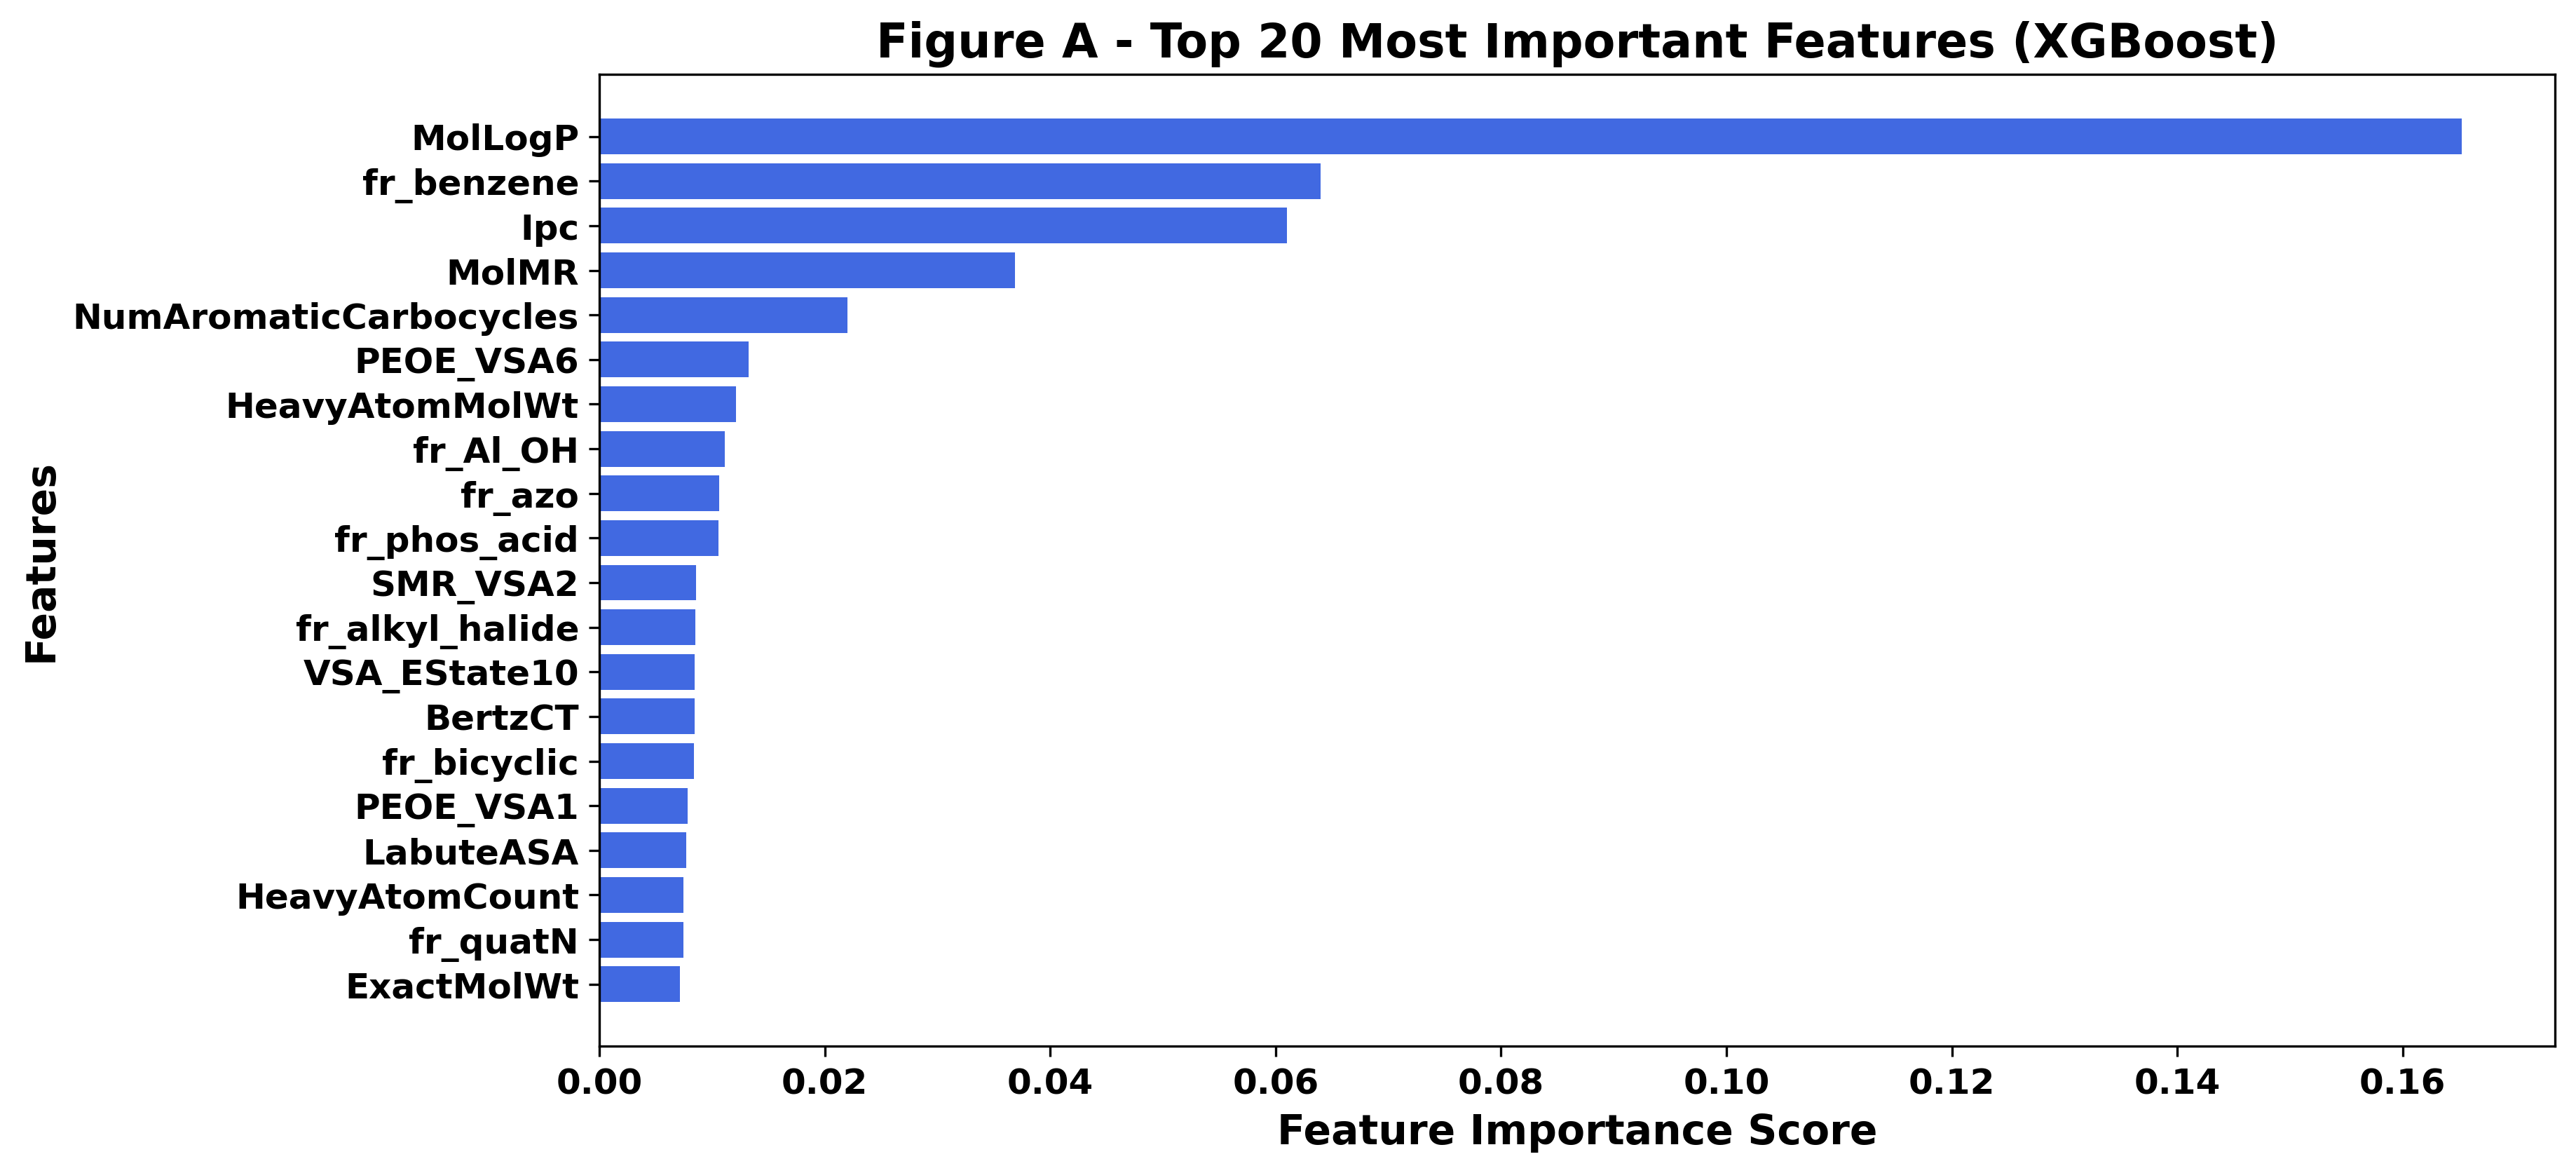

In [101]:
feat_importance(model=xgboost_model_193, data=df193_train)

### Random Forest for 193 features

In [87]:
randomforest_model = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=0
    )

df193_train_rf, y_train_rf  = drop_nan(X=df193_train, y=y_train)
df193_test_rf, y_test_rf  = drop_nan(X=df193_test, y=y_test)

print(f"XGB Datset Length; train: {len(df193_train)}  test  {len(df193_test)}")
print(f"RF Datset Length; train: {len(df193_train_rf)}  test  {len(df193_test_rf)}")

randomforest_model.fit(df193_train_rf,y_train_rf)

pred_rf = randomforest_model.predict(df193_test_rf)

rf_193=utilities.get_errors1(y_test_rf,pred_rf,"RF_193")
rf_193['Descriptors_Detail']='193 features'

XGB Datset Length; train: 17937  test  1282
RF Datset Length; train: 17522  test  1281


In [76]:
rf_193

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,RF_193,0.4387,0.3312,0.5755,0.9205,96 features


### xgboost for 394 features

In [17]:
def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = pd.Index(df.columns.astype(str).str.strip())
    # show what’s duplicated (optional)
    dups = cols[cols.duplicated()].unique()
    if len(dups):
        print("Duplicated columns:", list(dups))

    # add suffix _1, _2, ... to duplicates to make them unique
    counts = {}
    new_cols = []
    for c in cols:
        if c in counts:
            counts[c] += 1
            new_cols.append(f"{c}_{counts[c]}")
        else:
            counts[c] = 0
            new_cols.append(c)
    df = df.copy()
    df.columns = new_cols
    return df

In [60]:
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 

df394_train = make_unique_columns(df394_train.select_dtypes(include=[np.number]))
df394_test  = make_unique_columns(df394_test.select_dtypes(include=[np.number]))
xgboost_model.fit(df394_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model.predict(df394_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_394=utilities.get_errors1(y_test,pred_xgb,"XGB_394")
xgb_394['Descriptors_Detail']='394 features'

Duplicated columns: ['Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SM

In [61]:
xgb_394

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_394,0.4114,0.3108,0.5575,0.9255,394 features


### Random Forest for 394 features

In [88]:
randomforest_model = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=0
    )

df394_train_rf, y_train_rf  = drop_nan(X=df394_train, y=y_train)
df394_test_rf, y_test_rf  = drop_nan(X=df394_test, y=y_test)

print(f"XGB Datset Length; train: {len(df394_train)}  test  {len(df394_test)}")
print(f"RF Datset Length; train: {len(df394_train_rf)}  test  {len(df394_test_rf)}")

randomforest_model.fit(df394_train_rf,y_train_rf)

pred_rf = randomforest_model.predict(df394_test_rf)

rf_394=utilities.get_errors1(y_test_rf,pred_rf,"RF_394")
rf_394['Descriptors_Detail']='394 features'

XGB Datset Length; train: 17937  test  1282
RF Datset Length; train: 17522  test  1281


In [78]:
rf_394

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,RF_193,0.4356,0.3287,0.5733,0.9211,394 features


### xgboost for 491 features

In [18]:
xgboost_model_491 = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
### Fitting the model on train data 

df491_train = make_unique_columns(df491_train.select_dtypes(include=[np.number]))
df491_test  = make_unique_columns(df491_test.select_dtypes(include=[np.number]))
xgboost_model_491.fit(df491_train,y_train)    
### Predicting on test data 
pred_xgb = xgboost_model_491.predict(df491_test)
### Calculating the evaluation matrix MAE , RMSE and R2
xgb_491=utilities.get_errors1(y_test,pred_xgb,"XGB_491")
xgb_491['Descriptors_Detail']='491 features'

Duplicated columns: ['MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'HeavyAtomCount', 'MolLogP', 'MolMR', 'TPSA', 'FractionCSP3', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'RingCount', 'NumAromaticRings', 'NumAliphaticRings', 'NumSaturatedRings', 'NumAromaticHeterocycles', 'NumAromaticCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticCarbocycles', 'HallKierAlpha', 'LabuteASA', 'Kappa1', 'Kappa2', 'Kappa3', 'BertzCT', 'BalabanJ', 'Ipc', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'SMR_VSA1', 'SMR_VSA2', 'SMR_V

In [19]:
xgb_491

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_491,0.41,0.31,0.5568,0.9257,491 features


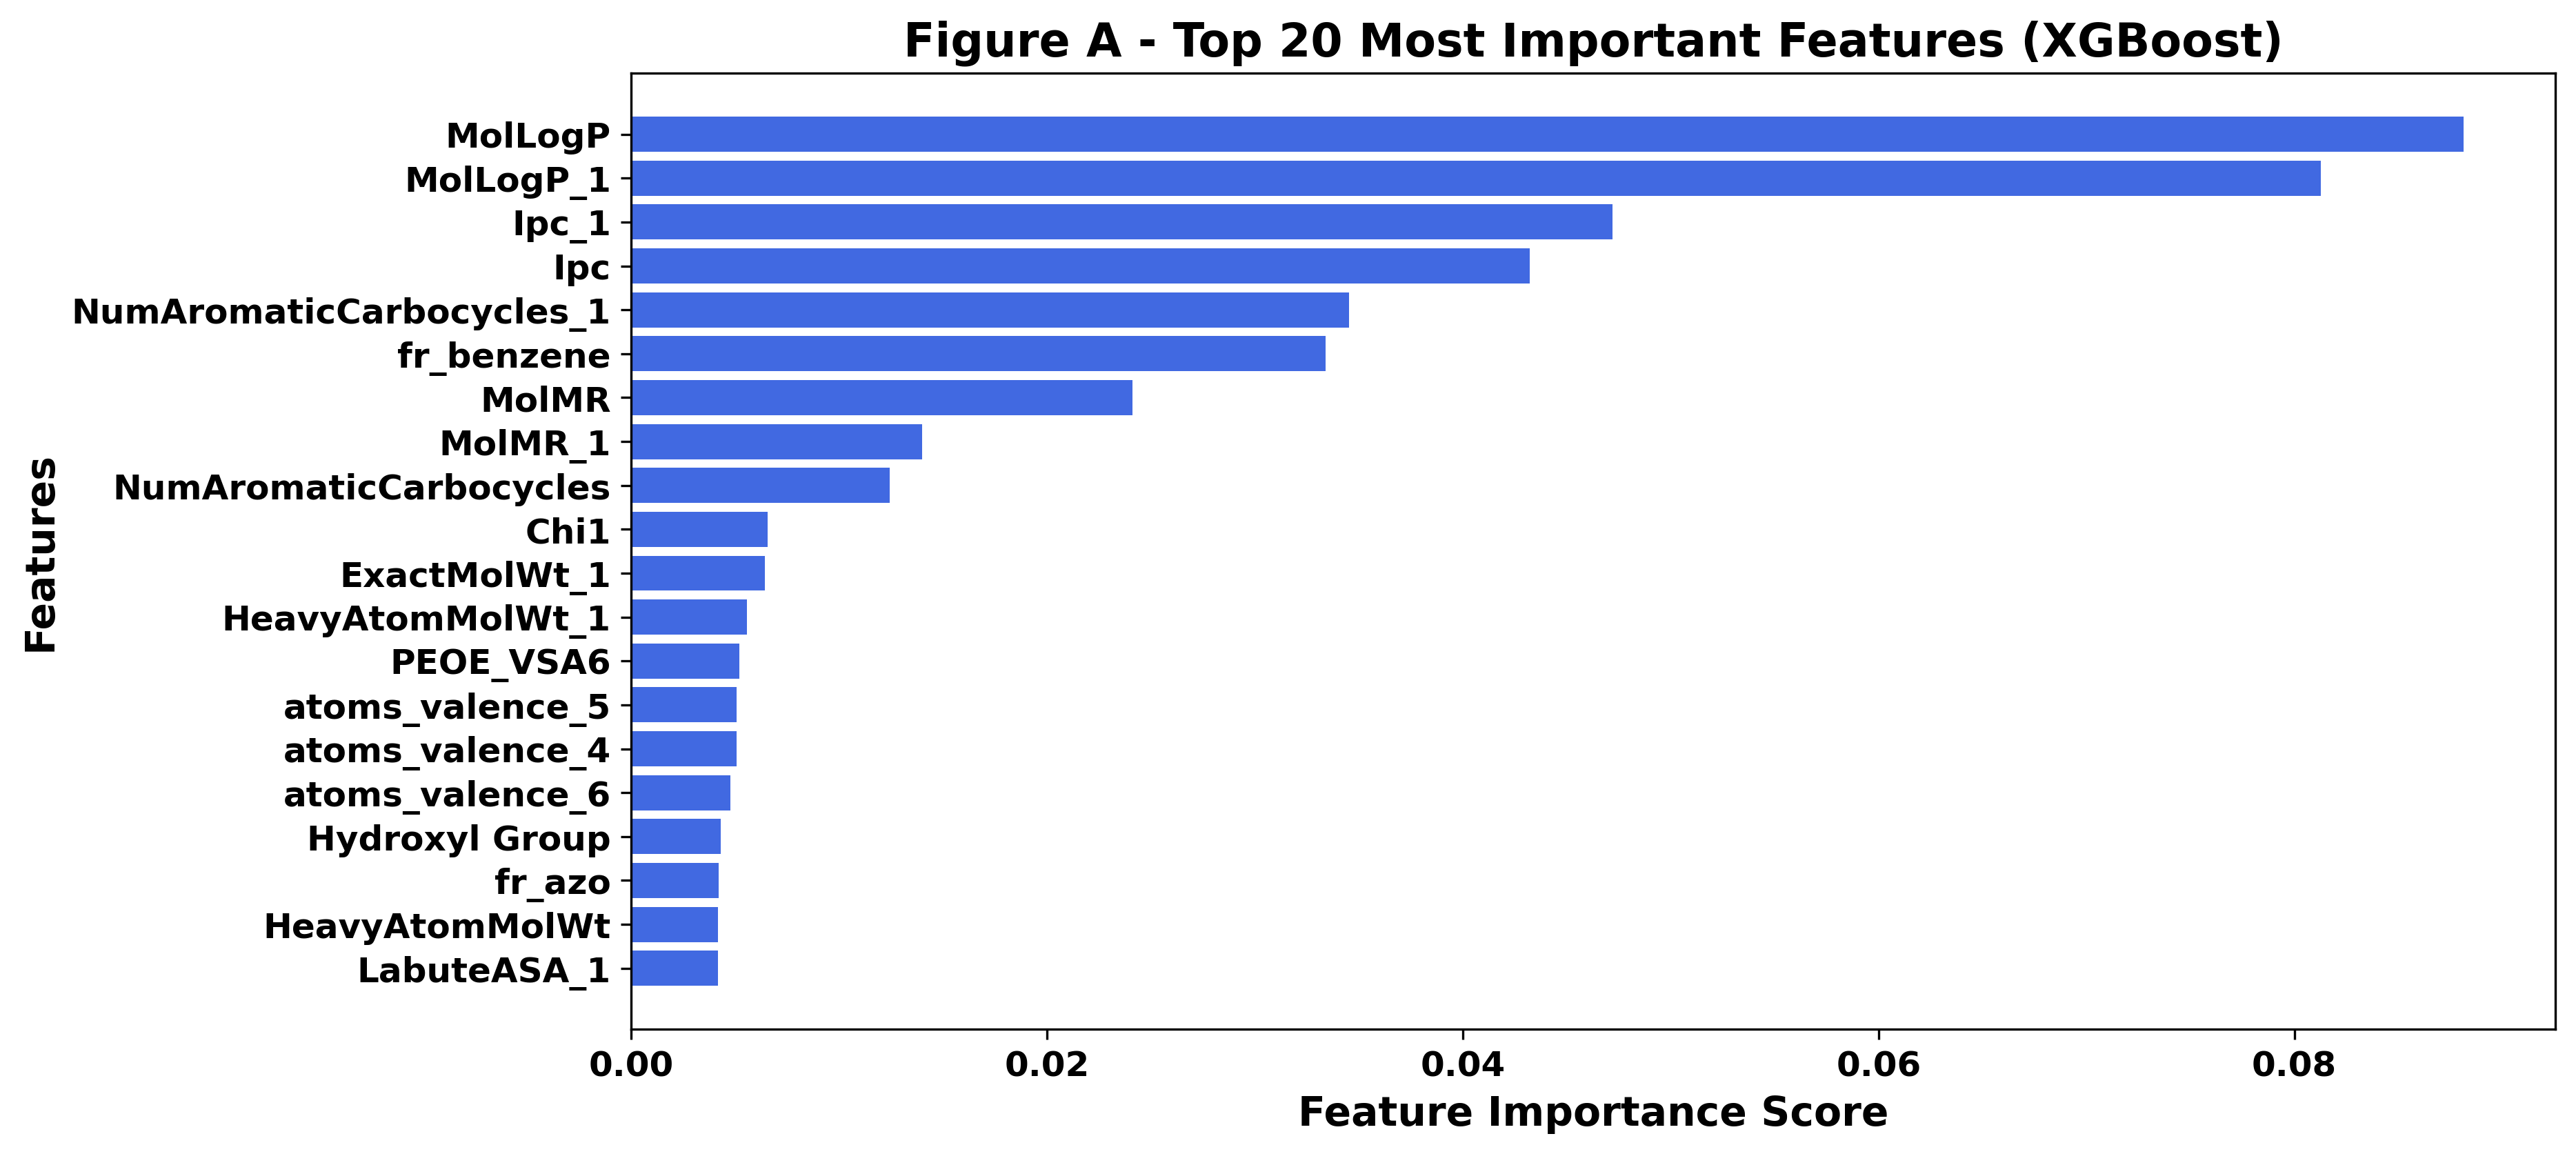

In [20]:
feat_importance(model=xgboost_model_491, data=df491_train)

### Random Forest for 491 features

In [ ]:
randomforest_model = RandomForestRegressor(
        n_estimators=800,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=0
    )

df491_train_rf, y_train_rf  = drop_nan(X=df491_train, y=y_train)
df491_test_rf, y_test_rf  = drop_nan(X=df491_test, y=y_test)

randomforest_model.fit(df491_train_rf,y_train_rf)

print(f"XGB Datset Length; train: {len(df491_train)}  test  {len(df491_test)}")
print(f"RF Datset Length; train: {len(df491_train_rf)}  test  {len(df491_test_rf)}")

pred_rf = randomforest_model.predict(df491_test_rf)

rf_491=utilities.get_errors1(y_test_rf,pred_rf,"RF_491")
rf_491['Descriptors_Detail']='491 features'

XGB Datset Length; train: 17937  test  1282
RF Datset Length; train: 17522  test  1281


In [80]:
rf_491

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,RF_491,0.4337,0.3254,0.5705,0.9219,491 features


In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lrs = [x for x in np.arange(100, 1000, 100)]
for lr in lrs:
    rf = RandomForestRegressor(
        n_estimators=lr,
        max_depth=None,           # let trees grow; tune if overfitting
        min_samples_leaf=2,       # small regularization
        max_features="sqrt",      # strong default for RF
        n_jobs=-1,
        random_state=42
    )
    df491_train = make_unique_columns(df491_train.select_dtypes(include=[np.number]))
    df491_test  = make_unique_columns(df491_test.select_dtypes(include=[np.number]))
    rf.fit(df491_train,y_train)

    pred = rf.predict(df491_test)

    # xgb_491=utilities.get_errors1(y_test,pred,"RF_491")
    rmse = mean_squared_error(y_test, pred, squared=False)
    print(rmse)

## Find best parameter set and do the regression

In [31]:
def topk_feature_names(model, data, k=20):
    """Return names of the top-k features by .feature_importances_."""
    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model has no .feature_importances_. Train a tree-based model first.")
    importances = np.asarray(model.feature_importances_)
    idx = np.argsort(importances)[::-1][:k]
    return list(data.columns[idx])

for k in range (400, 500, 20):
    feats = topk_feature_names(model=xgboost_model_491, data=df491_train, k=k)
    print(feats)

    xgboost_model_491_best_20 = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                            colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)

    xgboost_model_491_best_20.fit(df491_train[feats], y_train)

    ### Predicting on test data 
    pred_xgb = xgboost_model_491_best_20.predict(df491_test[feats])
    ### Calculating the evaluation matrix MAE , RMSE and R2
    xgb_491=utilities.get_errors1(y_test,pred_xgb,"XGB_491_best_20")
    xgb_491['Descriptors_Detail']='491 features best 20'
    print(k)
    print(xgb_491)


['MolLogP', 'MolLogP_1', 'Ipc_1', 'Ipc', 'NumAromaticCarbocycles_1', 'fr_benzene', 'MolMR', 'MolMR_1', 'NumAromaticCarbocycles', 'Chi1', 'ExactMolWt_1', 'HeavyAtomMolWt_1', 'PEOE_VSA6', 'atoms_valence_5', 'atoms_valence_4', 'atoms_valence_6', 'Hydroxyl Group', 'fr_azo', 'HeavyAtomMolWt', 'LabuteASA_1', 'SMR_VSA2_1', '39', 'fr_Al_OH', 'fr_phos_acid', 'BertzCT', 'conjugated_bonds', 'SlogP_VSA5_1', 'VSA_EState10', 'PEOE_VSA1', 'fr_bicyclic', 'Alkyl', 'fr_phos_ester', 'ExactMolWt', 'fr_alkyl_halide', 'Chi0', 'fr_Ndealkylation2', 'PEOE_VSA1_1', 'NumSaturatedCarbocycles', 'BertzCT_1', 'fr_COO2', 'NumSaturatedCarbocycles_1', 'BalabanJ', 'MolWt_1', 'SlogP_VSA2_1', 'VSA_EState9', 'Chi1n', 'Chi1v', 'BCUT2D_LOGPLOW', 'RingCount', 'aromatic_atoms', '116', 'SlogP_VSA2', 'LabuteASA', 'fr_Al_OH_noTert', 'BCUT2D_LOGPLOW_1', 'fr_nitro', 'SlogP_VSA5', 'SMR_VSA2', 'SlogP_VSA4_1', 'BalabanJ_1', 'fr_COO', 'SlogP_VSA4', 'VSA_EState9_1', 'VSA_EState10_1', 'fr_pyridine', 'SMR_VSA1_1', 'atom_hybridization_SP2'

In [28]:
xgb_491

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_491_best_20,0.4943,0.4157,0.6447,0.9003,491 features best 20


In [25]:
xgb_491

,Model_Name,MAE,MSE,RMSE,R2,Descriptors_Detail
0,XGB_491_best_20,0.4943,0.4157,0.6447,0.9003,491 features best 20


## Drop NaN data


In [30]:
def drop_nan(X, y):
    XY = pd.concat([X, y], axis=1, join="inner")          # align on index
    XY = XY.replace([np.inf, -np.inf], np.nan)

    dropped = XY.isna().any(axis=1).sum()
    XY = XY.dropna(axis=0, how="any")
    n_features = X.shape[1]
    X_clean = XY.iloc[:, :n_features]
    y_clean = XY.iloc[:, n_features]
    return X_clean, y_clean


df17_train, y_train_17 = drop_nan(df17_train, y_train)
df17_test, y_test_17 = drop_nan(df17_test, y_test)

df123_train, y_train_123 = drop_nan(df123_train, y_train)
df123_test, y_test_123 = drop_nan(df123_test, y_test)

df253_train, y_train_253 = drop_nan(df253_train, y_train)
df253_test, y_test_253 = drop_nan(df253_test, y_test)

df260_train, y_train_260 = drop_nan(df260_train, y_train)
df260_test, y_test_260 = drop_nan(df260_test, y_test)

df298_train, y_train_298 = drop_nan(df298_train, y_train)
df298_test, y_test_298 = drop_nan(df298_test, y_test)

# Rabdom Projection Experiment

In [31]:
n_components = 500 #500 #1000


def RP(train, test):
    projector = GaussianRandomProjection(n_components=n_components, random_state=42)
    X_train_projected = projector.fit_transform(train)
    X_test_projected = projector.transform(test)
    return X_train_projected, X_test_projected

X_train_projected_4, X_test_projected_4 = RP(df4_train, df4_test)
# X_train_projected_17, X_test_projected_17 = RP(df17_train, df17_test)
# X_train_projected_123, X_test_projected_123 = RP(df123_train, df123_test)
# X_train_projected_253, X_test_projected_253 = RP(df253_train, df253_test)
# X_train_projected_260, X_test_projected_260 = RP(df260_train, df260_test)
# X_train_projected_298, X_test_projected_298 = RP(df298_train, df298_test)



In [32]:
regressor_4 = XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                            colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)

regressor_4.fit(df4_train, y_train)
y_pred_4 = regressor_4.predict(df4_test)
mae_4 = mean_absolute_error(y_test, y_pred_4)
mse_4 = mean_squared_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)
print(f"\n XGBoost org {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4}")



 XGBoost org 500 MAE: 0.5531  |  MSE: 0.5095374417332084  |  R2: 0.8778298464829742


In [33]:
regressor_4 = XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                            colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
# regressor_17 = XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=4)
# regressor_123 = XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=4)
# regressor_253 = XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=4)
# regressor_260 = XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=4)
# regressor_298 = XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.1, max_depth=4)
# regressor_298_ = XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
#                                            colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
regressor_4.fit(X_train_projected_4, y_train)
# regressor_17.fit(X_train_projected_17, y_train_17)
# regressor_253.fit(X_train_projected_253, y_train_253)
# regressor_260.fit(X_train_projected_260, y_train_260)
# regressor_298.fit(X_train_projected_298, y_train_298)

y_pred_4 = regressor_4.predict(X_test_projected_4)
# y_pred_17 = regressor_17.predict(X_test_projected_17)
# y_pred_253 = regressor_253.predict(X_test_projected_253)
# y_pred_260 = regressor_260.predict(X_test_projected_260)
# y_pred_298 = regressor_298.predict(X_test_projected_298)

In [34]:
mae_4 = mean_absolute_error(y_test, y_pred_4)
mse_4 = mean_squared_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)
print(f"\n XGBoost RProjected {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4}")


 XGBoost RProjected 500 MAE: 0.5350  |  MSE: 0.49433520194744884  |  R2: 0.8814748386195901


In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import Ridge, ridge_regression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
gamma = 1/1000

def ridge_model():
    alphas = 10.0 ** np.arange(-8, 5)
    model = RidgeCV(
        alphas=alphas,
        cv=5,
        scoring="neg_mean_squared_error"   # change to "accuracy", "f1_macro", etc. if you prefer
    )
    return model

def svc(c):
    gamma = 0.001 # rough start; tune later

    svr_rbf = make_pipeline(
        StandardScaler(with_mean=False),
        SVR(kernel='rbf', C=c, epsilon=0.1, gamma=gamma)
    )
    return svr_rbf
    

In [36]:
model_4 = ridge_model()
model_4.fit(X_train_projected_4, y_train)
y_pred_4 = model_4.predict(X_test_projected_4)
mae_4 = mean_absolute_error(y_test, y_pred_4)
mse_4 = mean_squared_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)
print(f"\n Ridge RProjected {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4} alpha {model_4.alpha_}")
del model_4


model_4 = ridge_model()
model_4.fit(df4_train, y_train)
y_pred_4 = model_4.predict(df4_test)
mae_4 = mean_absolute_error(y_test, y_pred_4)
mse_4 = mean_squared_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)
print(f"\n Ridge Original {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4} alpha {model_4.alpha_}")
del model_4





 Ridge RProjected 500 MAE: 0.7876  |  MSE: 1.0265853821577546  |  R2: 0.7538589248516583 alpha 1000.0

 Ridge Original 500 MAE: 0.7875  |  MSE: 1.0261666019965332  |  R2: 0.7539593344239407 alpha 1000.0


In [37]:
Cs = [0.01, 0.1, 1, 2,3,4,5,6]

for c in Cs:
    model_4 = svc(c)
    model_4.fit(X_train_projected_4, y_train)
    y_pred_4 = model_4.predict(X_test_projected_4)
    mae_4 = mean_absolute_error(y_test, y_pred_4)
    mse_4 = mean_squared_error(y_test, y_pred_4)
    r2_4 = r2_score(y_test, y_pred_4)
    print(f"\n SVC  RProjected c {c} {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4}")
    del model_4


    model_4 = svc(c)
    model_4.fit(df4_train, y_train)
    y_pred_4 = model_4.predict(df4_test)
    mae_4 = mean_absolute_error(y_test, y_pred_4)
    mse_4 = mean_squared_error(y_test, y_pred_4)
    r2_4 = r2_score(y_test, y_pred_4)
    print(f"\n SVC Original c {c} {n_components} MAE: {mae_4:.4f}  |  MSE: {mse_4}  |  R2: {r2_4}")
    del model_4


 SVC  RProjected c 0.01 500 MAE: 1.0693  |  MSE: 2.081834237774153  |  R2: 0.500845300865959

 SVC Original c 0.01 500 MAE: 1.4369  |  MSE: 3.411433620732926  |  R2: 0.182051533366401

 SVC  RProjected c 0.1 500 MAE: 0.8186  |  MSE: 1.1701165680096821  |  R2: 0.7194449140767796

 SVC Original c 0.1 500 MAE: 0.9272  |  MSE: 1.4656019114487997  |  R2: 0.6485973436858885

 SVC  RProjected c 1 500 MAE: 0.7137  |  MSE: 0.8786454699453726  |  R2: 0.7893300017656595

 SVC Original c 1 500 MAE: 0.7521  |  MSE: 0.9412076964674956  |  R2: 0.7743296579389605

 SVC  RProjected c 2 500 MAE: 0.6945  |  MSE: 0.8274207399363823  |  R2: 0.8016119905195758

 SVC Original c 2 500 MAE: 0.7387  |  MSE: 0.9058016936385761  |  R2: 0.7828188413566105

 SVC  RProjected c 3 500 MAE: 0.6842  |  MSE: 0.8017211386249451  |  R2: 0.8077739012652606

 SVC Original c 3 500 MAE: 0.7317  |  MSE: 0.8889752476625549  |  R2: 0.7868532641873331

 SVC  RProjected c 4 500 MAE: 0.6767  |  MSE: 0.7830886257321938  |  R2: 0.812

KeyboardInterrupt: 

dim 100
XGBOOSt
MAE: 0.5692  |  MSE: 0.5515608283348477  |  R2: 0.8677540342424368

Rdige
R projected MAE: 0.7887  |  MSE: 1.029868440266331  |  R2: 0.7530717565686647

Original MAE: 0.7875  |  MSE: 1.0261666019965332  |  R2: 0.7539593344239407

SVC
R projected MAE: 0.7581  |  MSE: 0.9928532848482776  |  R2: 0.7619467613268978

Original MAE: 0.7387  |  MSE: 0.9058016936385761  |  R2: 0.7828188413566105

In [30]:
for r in range (1,10,1):
    print(r)

1
2
3
4
5
6
7
8
9
